In [46]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd

# Loaded Data

In [47]:
copper = pd.read_csv('skin_depth_data/Skin Depth - Copper.csv')

copper_freq = copper['Frequency (Hz)']
copper_invfreq = copper['Hz^-1']
copper_current = copper['Solenoid current (A) (±0.1mA)']
copper_pickupvolt =  copper['Pick-up voltage']
copper_voltrat = copper['Voltage ratio (V/f)']
copper_tlag = copper['Time lag (s)']
copper_phase = copper['Phase shift']

In [48]:
alumin = pd.read_csv('skin_depth_data/Skin Depth - Aluminium.csv')

alumin_freq = alumin['Frequency (Hz)']
alumin_invfreq = alumin['Hz^-1']
alumin_current = alumin['Solenoid current (A) (±0.1mA)']
alumin_pickupvolt =  alumin['Pick-up voltage']
alumin_voltrat = alumin['Voltage ratio (V/f)']
alumin_tlag = alumin['Time lag (s)']
alumin_phase = alumin['Phase shift']

In [49]:
brass = pd.read_csv('skin_depth_data/Skin Depth - Brass.csv')

brass_freq = brass['Frequency (Hz)']
brass_invfreq = brass['Hz^-1']
brass_current = brass['Solenoid current (A) (±0.1mA)']
brass_pickupvolt =  brass['Pick-up voltage']
brass_voltrat = brass['Voltage ratio (V/f)']
brass_tlag = brass['Time lag (s)']
brass_phase = brass['Phase shift']

In [50]:
steel = pd.read_csv('skin_depth_data/Skin Depth - Steel.csv')

steel_freq = steel['Frequency (Hz)']
steel_invfreq = steel['Hz^-1']
steel_current = steel['Solenoid current (A) (±0.1mA)']
steel_pickupvolt =  steel['Pick-up voltage']
steel_voltrat = steel['Voltage ratio (V/f)']
steel_tlag = steel['Time lag (s)']
steel_phase = steel['Phase shift']

# Skin Depth

In [61]:
xcopper = 1 / np.sqrt(copper_freq)
d_freq = 3
xcopper_err = 1/2 * (copper_freq ** (-3/2)) * d_freq # error propagation

ycopper = copper_voltrat
d_volt = 2e-5
ycopper_err = ycopper * np.sqrt((d_volt / copper_pickupvolt)**2 + (d_freq / copper_freq)**2) # error propagation

acopper, bcopper = np.polyfit(xcopper, ycopper, 1) # linear fit

In [ ]:
xalumin = 1 / np.sqrt(alumin_freq)
d_freq = 3
xalumin_err = 1/2 * (alumin_freq ** (-3/2)) * d_freq # error propagation

yalumin = alumin_voltrat
d_volt = 2e-4
yalumin_err = yalumin * np.sqrt((d_volt / alumin_pickupvolt)**2 + (d_freq / alumin_freq)**2) # error propagation

aalumin, balumin = np.polyfit(xalumin, yalumin, 1) # linear fit

In [66]:
xbrass= 1 / np.sqrt(brass_freq)
d_freq = 3
xbrass_err = 1/2 * (brass_freq ** (-3/2)) * d_freq # error propagation

ybrass = brass_voltrat
d_volt = 2e-4
ybrass_err = ybrass * np.sqrt((d_volt / brass_pickupvolt)**2 + (d_freq / brass_freq)**2) # error propagation

abrass, bbrass = np.polyfit(xbrass, ybrass, 1) # linear fit

In [64]:
xsteel = 1 / np.sqrt(steel_freq)
d_freq = 3
xsteel_err = 1/2 * (steel_freq ** (-3/2)) * d_freq # error propagation

ysteel = steel_voltrat
d_volt = 2e-3
ysteel_err = ysteel * np.sqrt((d_volt / steel_pickupvolt)**2 + (d_freq / steel_freq)**2) # error propagation

asteel, bsteel = np.polyfit(xsteel, ysteel, 1) # linear fit

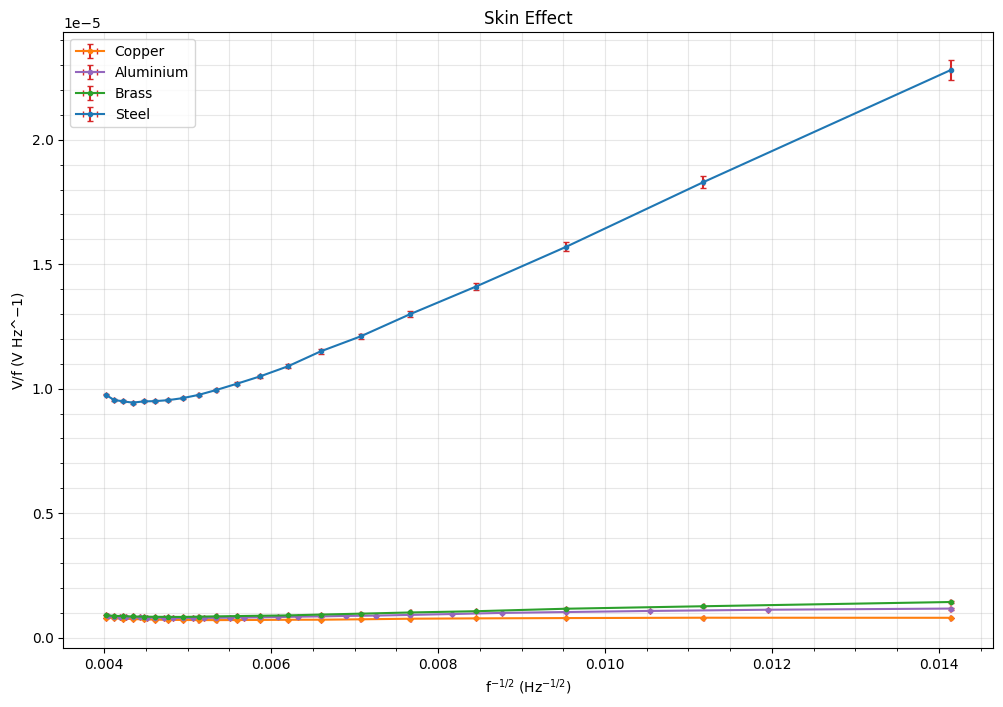

In [205]:
plt.figure(figsize=(12,8))

plt.errorbar(xcopper, ycopper, marker='.', xerr=xcopper_err, yerr=ycopper_err, color='tab:orange', ecolor='tab:red', capsize=2, label='Copper')
plt.errorbar(xalumin, yalumin, marker='.', xerr=xalumin_err, yerr=yalumin_err, color='tab:purple', ecolor='tab:red', capsize=2, label='Aluminium')
plt.errorbar(xbrass, ybrass, marker='.', xerr=xbrass_err, yerr=ybrass_err, color='tab:green', ecolor='tab:red', capsize=2, label='Brass')
plt.errorbar(xsteel, ysteel, marker='.', xerr=xsteel_err, yerr=ysteel_err, color='tab:blue', ecolor='tab:red', capsize=2, label='Steel')

plt.xlabel(r'f$^{-1/2}$ (Hz$^{-1/2}$)')
plt.ylabel(r'V/f (V Hz^${-1}$)')
plt.legend()
plt.minorticks_on()
plt.grid(which='both', alpha=0.3)

plt.title('Skin Effect')
plt.show()

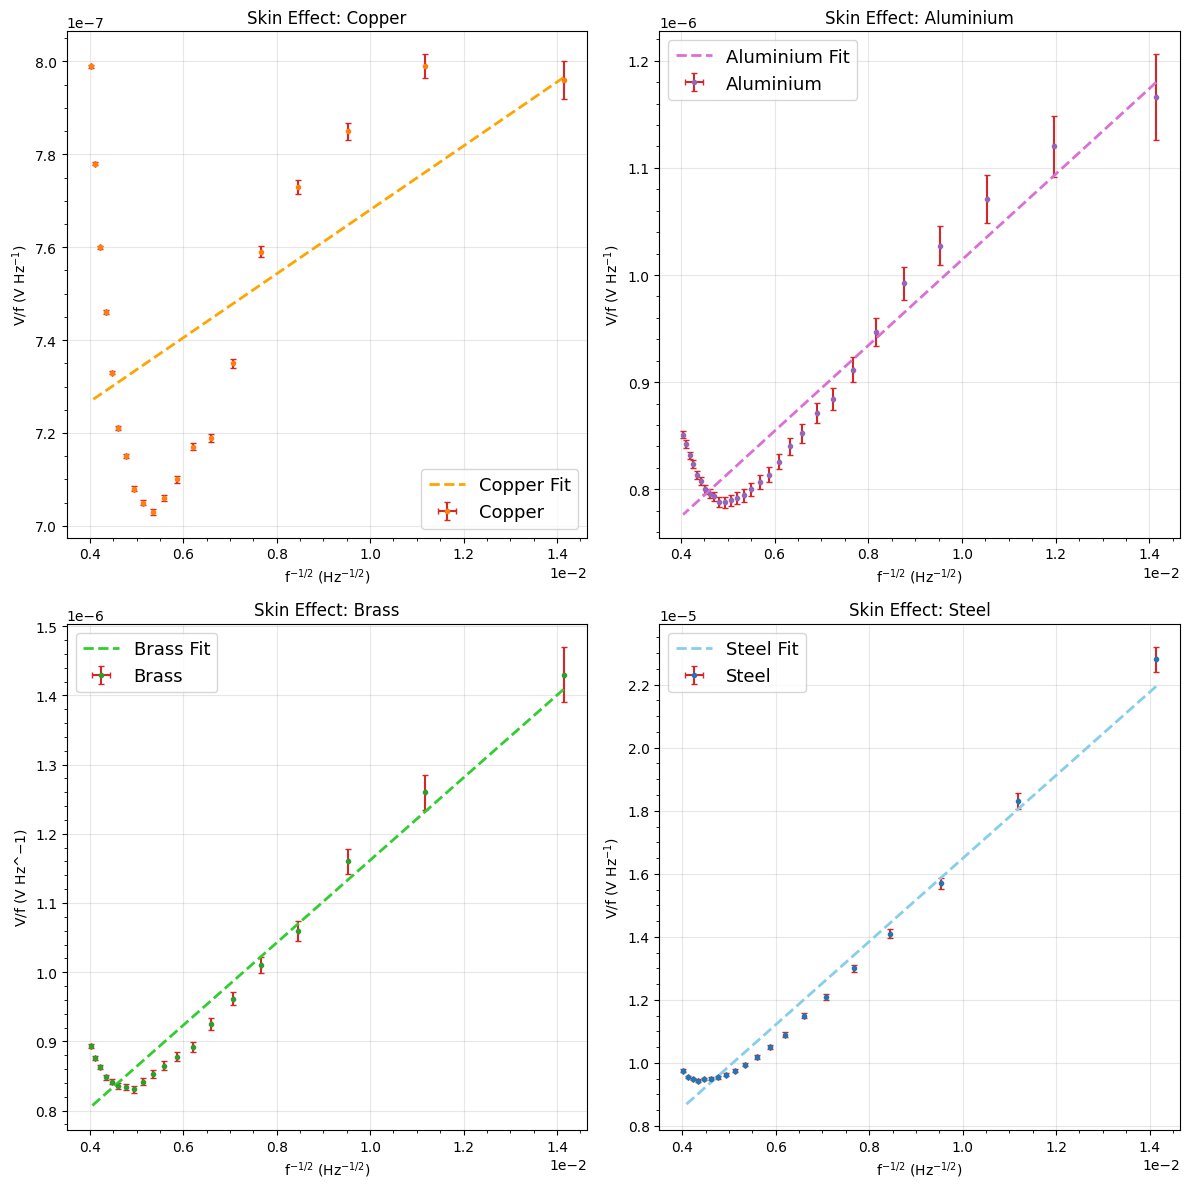

Copper Slope = 6.881107715242963e-06
Aluminium Slope = 3.997666079342883e-05
Brass Slope = 5.960994412577555e-05
Steel Slope = 0.0013182287889296


In [204]:
fig, ax = plt.subplots(2,2, figsize=(12,12))

ax[0,0].errorbar(xcopper, ycopper, fmt='.', xerr=xcopper_err, yerr=ycopper_err, capsize=2, color='tab:orange', ecolor='tab:red', label='Copper')
ax[0,0].plot(xcopper, acopper*xcopper+bcopper, color='orange', linestyle='--', linewidth=2, label='Copper Fit')
ax[0,0].set_title('Skin Effect: Copper')
ax[0,0].set_xlabel(r'f$^{-1/2}$ (Hz$^{-1/2}$)')
ax[0,0].set_ylabel(r'V/f (V Hz$^{-1}$)')
ax[0,0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[0,0].minorticks_on()
ax[0,0].grid(which='major', alpha=0.3)
ax[0,0].legend(fontsize=13)

ax[0,1].errorbar(xalumin, yalumin, fmt='.', xerr=xalumin_err, yerr=yalumin_err, capsize=2, color='tab:purple', ecolor='tab:red', label='Aluminium')
ax[0,1].plot(xalumin, aalumin*xalumin+balumin, color='orchid', linestyle='--', linewidth=2, label='Aluminium Fit')
ax[0,1].set_title('Skin Effect: Aluminium')
ax[0,1].set_xlabel(r'f$^{-1/2}$ (Hz$^{-1/2}$)')
ax[0,1].set_ylabel(r'V/f (V Hz$^{-1}$)')
ax[0,1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[0,1].minorticks_on()
ax[0,1].grid(which='major', alpha=0.3)
ax[0,1].legend(fontsize=13)

ax[1,0].errorbar(xbrass, ybrass, fmt='.', xerr=xbrass_err, yerr=ybrass_err, capsize=2, color='tab:green', ecolor='tab:red', label='Brass')
ax[1,0].plot(xbrass, abrass*xbrass+bbrass, color='limegreen', linestyle='--', linewidth=2, label='Brass Fit')
ax[1,0].set_title('Skin Effect: Brass')
ax[1,0].set_xlabel(r'f$^{-1/2}$ (Hz$^{-1/2}$)')
ax[1,0].set_ylabel(r'V/f (V Hz^${-1}$)')
ax[1,0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[1,0].minorticks_on()
ax[1,0].grid(which='major', alpha=0.3)
ax[1,0].legend(fontsize=13)

ax[1,1].errorbar(xsteel, ysteel, fmt='.', xerr=xsteel_err, yerr=ysteel_err, capsize=2, color='tab:blue', ecolor='tab:red', label='Steel')
ax[1,1].plot(xsteel, asteel*xsteel+bsteel, color='skyblue', linestyle='--', linewidth=2, label='Steel Fit')
ax[1,1].set_title('Skin Effect: Steel')
ax[1,1].set_xlabel(r'f$^{-1/2}$ (Hz$^{-1/2}$)')
ax[1,1].set_ylabel(r'V/f (V Hz$^{-1}$)')
ax[1,1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[1,1].minorticks_on()
ax[1,1].grid(which='major', alpha=0.3)
ax[1,1].legend(fontsize=13)

plt.tight_layout()
plt.show()

print(f'Copper Slope = {acopper}')
print(f'Aluminium Slope = {aalumin}')
print(f'Brass Slope = {abrass}')
print(f'Steel Slope = {asteel}')

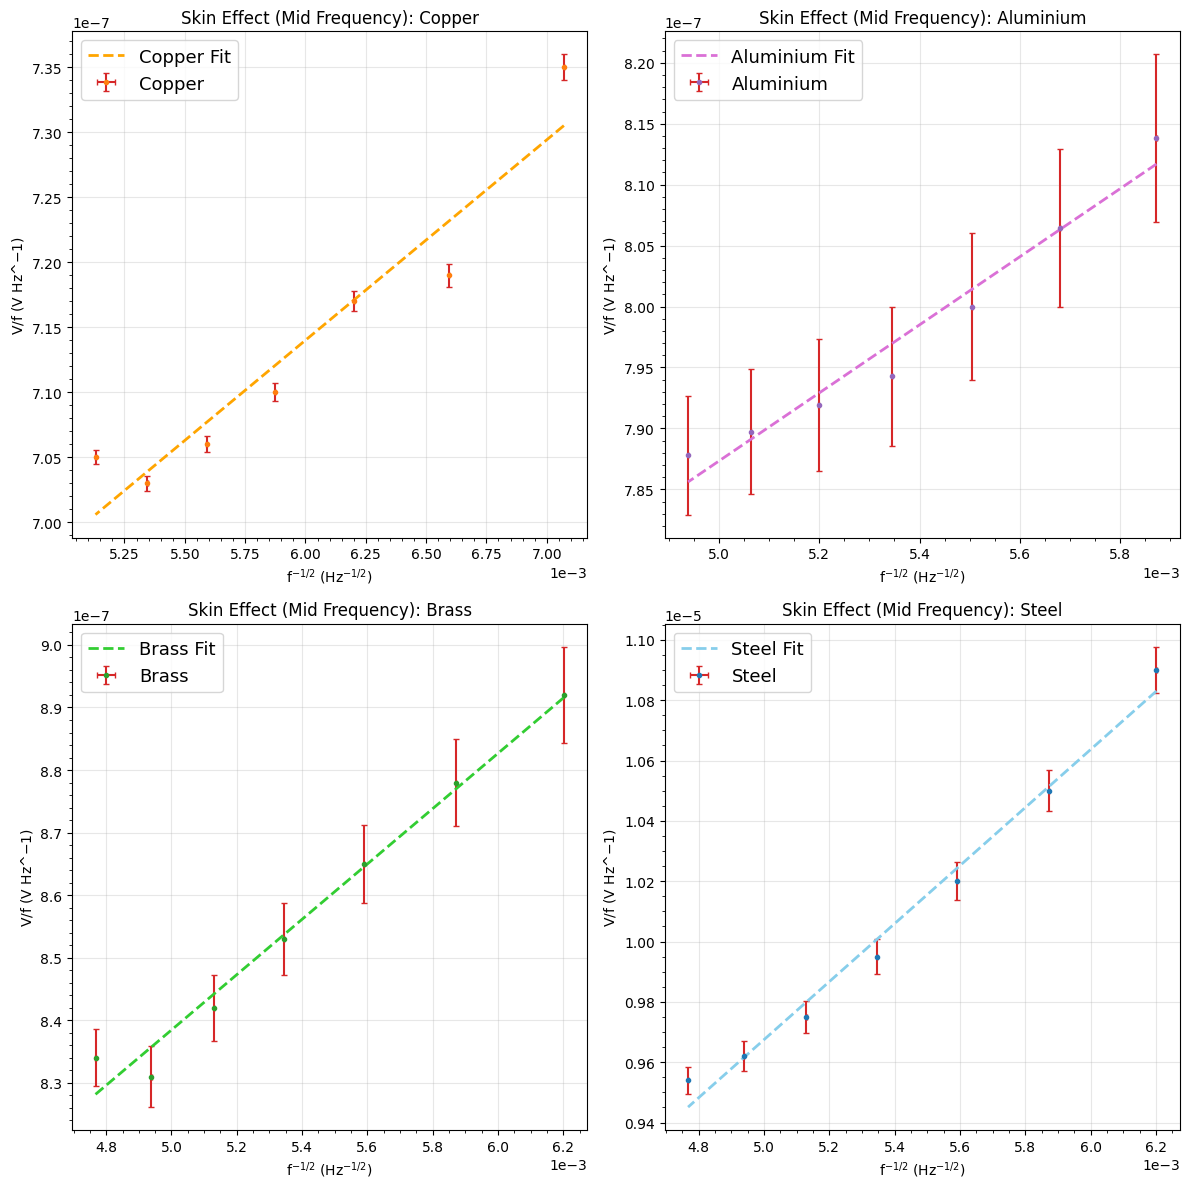

Copper Slope = 1.54231404201902e-05
Aluminium Slope = 2.793612431679689e-05
Brass Slope = 4.4219964481464906e-05
Steel Slope = 0.0009614122298156845


In [197]:
xcopperc, ycopperc = (xcopper[5:12]), (ycopper[5:12]) # high frequency ranges near the dip where the skin effect still holds
acopperc, bcopperc = np.polyfit(xcopperc, ycopperc, 1)

xaluminc, yaluminc = (xalumin[12:19]), (yalumin[12:19])
aaluminc, baluminc = np.polyfit(xaluminc, yaluminc, 1)

xbrassc, ybrassc = (xbrass[7:14]), (ybrass[7:14])
abrassc, bbrassc = np.polyfit(xbrassc, ybrassc, 1)

xsteelc, ysteelc = (xsteel[7:14]), (ysteel[7:14])
asteelc, bsteelc = np.polyfit(xsteelc, ysteelc, 1)

fig, ax = plt.subplots(2,2, figsize=(12,12))

ax[0,0].errorbar(xcopperc, ycopperc, fmt='.', xerr=xcopper_err[5:12], yerr=ycopper_err[5:12], capsize=2, color='tab:orange', ecolor='tab:red', label='Copper')
ax[0,0].plot(xcopperc, acopperc*xcopperc+bcopperc, color='orange', linestyle='--', linewidth=2, label='Copper Fit')
ax[0,0].set_title('Skin Effect (Mid Frequency): Copper')
ax[0,0].set_xlabel(r'f$^{-1/2}$ (Hz$^{-1/2}$)')
ax[0,0].set_ylabel(r'V/f (V Hz^${-1}$)')
ax[0,0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[0,0].minorticks_on()
ax[0,0].grid(which='major', alpha=0.3)
ax[0,0].legend(fontsize=13)

ax[0,1].errorbar(xaluminc, yaluminc, fmt='.', xerr=xalumin_err[12:19], yerr=yalumin_err[12:19], capsize=2, color='tab:purple', ecolor='tab:red', label='Aluminium')
ax[0,1].plot(xaluminc, aaluminc*xaluminc+baluminc, color='orchid', linestyle='--', linewidth=2, label='Aluminium Fit')
ax[0,1].set_title('Skin Effect (Mid Frequency): Aluminium')
ax[0,1].set_xlabel(r'f$^{-1/2}$ (Hz$^{-1/2}$)')
ax[0,1].set_ylabel(r'V/f (V Hz^${-1}$)')
ax[0,1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[0,1].minorticks_on()
ax[0,1].grid(which='major', alpha=0.3)
ax[0,1].legend(fontsize=13)

ax[1,0].errorbar(xbrassc, ybrassc, fmt='.', xerr=xbrass_err[7:14], yerr=ybrass_err[7:14], capsize=2, color='tab:green', ecolor='tab:red', label='Brass')
ax[1,0].plot(xbrassc, abrassc*xbrassc+bbrassc, color='limegreen', linestyle='--', linewidth=2, label='Brass Fit')
ax[1,0].set_title('Skin Effect (Mid Frequency): Brass')
ax[1,0].set_xlabel(r'f$^{-1/2}$ (Hz$^{-1/2}$)')
ax[1,0].set_ylabel(r'V/f (V Hz^${-1}$)')
ax[1,0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[1,0].minorticks_on()
ax[1,0].grid(which='major', alpha=0.3)
ax[1,0].legend(fontsize=13)

ax[1,1].errorbar(xsteelc, ysteelc, fmt='.', xerr=xsteel_err[7:14], yerr=ysteel_err[7:14], capsize=2, color='tab:blue', ecolor='tab:red', label='Steel')
ax[1,1].plot(xsteelc, asteelc*xsteelc+bsteelc, color='skyblue', linestyle='--', linewidth=2, label='Steel Fit')
ax[1,1].set_title('Skin Effect (Mid Frequency): Steel')
ax[1,1].set_xlabel(r'f$^{-1/2}$ (Hz$^{-1/2}$)')
ax[1,1].set_ylabel(r'V/f (V Hz^${-1}$)')
ax[1,1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[1,1].minorticks_on()
ax[1,1].grid(which='major', alpha=0.3) 
ax[1,1].legend(fontsize=13)

plt.tight_layout()
plt.show()

print(f'Copper Slope = {acopperc}')
print(f'Aluminium Slope = {aaluminc}')
print(f'Brass Slope = {abrassc}')
print(f'Steel Slope = {asteelc}')

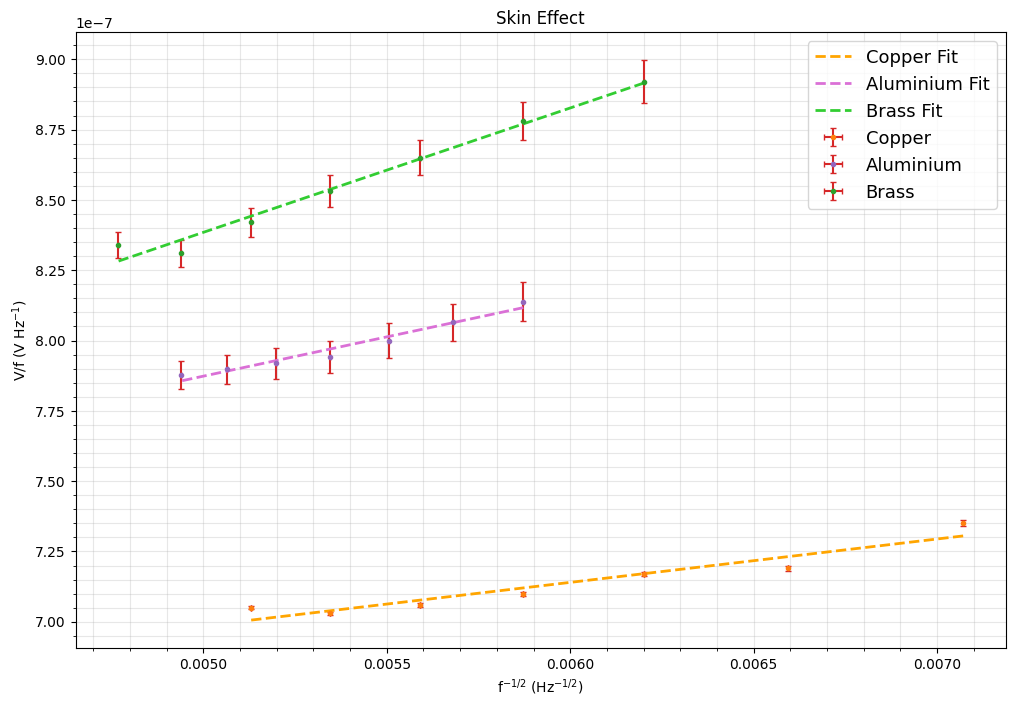

In [198]:
plt.figure(figsize=(12,8))

plt.errorbar(xcopperc, ycopperc, marker='.', xerr=xcopper_err[5:12], yerr=ycopper_err[5:12], color='tab:orange', ecolor='tab:red', capsize=2, label='Copper', linestyle='None')
plt.plot(xcopperc, acopperc*xcopperc+bcopperc, color='orange', linestyle='--', linewidth=2, label='Copper Fit')
plt.errorbar(xaluminc, yaluminc, marker='.', xerr=xalumin_err[12:19], yerr=yalumin_err[12:19], color='tab:purple', ecolor='tab:red', capsize=2, label='Aluminium', linestyle='None')
plt.plot(xaluminc, aaluminc*xaluminc+baluminc, color='orchid', linestyle='--', linewidth=2, label='Aluminium Fit')
plt.errorbar(xbrassc, ybrassc, marker='.', xerr=xbrass_err[7:14], yerr=ybrass_err[7:14], color='tab:green', ecolor='tab:red', capsize=2, label='Brass', linestyle='None')
plt.plot(xbrassc, abrassc*xbrassc+bbrassc, color='limegreen', linestyle='--', linewidth=2, label='Brass Fit')

plt.xlabel(r'f$^{-1/2}$ (Hz$^{-1/2}$)')
plt.ylabel(r'V/f (V Hz$^{-1}$)')
plt.legend(fontsize=13)
plt.minorticks_on()
plt.grid(which='both', alpha=0.3)

plt.title('Skin Effect')
plt.show()

In [137]:
mu = 4 * np.pi * 1e-7 # first term mu_0, mu_r just 1 for Copper, Aluminium, Brass

N = 1013 # turns in solenoid
n = 100 # turns in pickup solenoid
I = 1.9e-2 # steady current
dI = 0.5e-3
R = 0.95e-2 / 2 # radius of rod (metres)
dR = 0.05e-2 / 2
A = np.pi * (R**2)
L = 40.5e-2 # length of solenoid
dL = 0.05e-2

flux = mu * (N / L) * I * A

cond_copper = 2 * (flux / ((acopperc / n) * R))**2 / mu
cond_alumin = 2 * (flux / ((aaluminc / n) * R))**2 / mu
cond_brass = 2 * (flux / ((abrassc / n) * R))**2 / mu

params_copper, cov_copper = np.polyfit(xcopperc, ycopperc, 1, cov=True)
da_copper = np.sqrt(cov_copper[0,0])
params_alumin, cov_alumin = np.polyfit(xaluminc, yaluminc, 1, cov=True)
da_alumin = np.sqrt(cov_alumin[0,0])
params_brass, cov_brass = np.polyfit(xbrassc, ybrassc, 1, cov=True)
da_brass = np.sqrt(cov_brass[0,0])

cond_copper_err = cond_copper * np.sqrt((2 * dI / I)**2 + (2 * dR / R)**2 + (2 * dL / L)**2 + (2 * da_copper / acopperc)**2)
cond_alumin_err = cond_alumin * np.sqrt((2 * dI / I)**2 + (2 * dR / R)**2 + (2 * dL / L)**2 + (2 * da_alumin / aaluminc)**2)
cond_brass_err = cond_brass * np.sqrt((2 * dI / I)**2 + (2 * dR / R)**2 + (2 * dL / L)**2 + (2 * da_brass / abrassc)**2)

print(f'Copper conductivity: {cond_copper:.2e} ± {cond_copper_err:.2e} S/m')
print(f'Aluminium conductivity: {cond_alumin:.2e} ± {cond_alumin_err:.2e} S/m')
print(f'Brass conductivity: {cond_brass:.2e} ± {cond_brass_err:.2e} S/m')

Copper conductivity: 5.31e+07 ± 1.58e+07 S/m
Aluminium conductivity: 1.62e+07 ± 3.40e+06 S/m
Brass conductivity: 6.46e+06 ± 1.12e+06 S/m


In [144]:
cond_steel = 1.45e6 # https://www.thoughtco.com/table-of-electrical-resistivity-conductivity-608499

params_steel, cov_steel = np.polyfit(xsteelc, ysteelc, 1, cov=True)
da_steel = np.sqrt(cov_steel[0,0])

perm_steel = (mu * cond_steel / 2) * ((asteelc / n) * R / flux)**2
perm_steel_err = perm_steel * np.sqrt((2 * dI / I)**2 + (2 * dR / R)**2 + (2 * dL / L)**2 + (2 * da_steel / asteelc)**2)

print(f'Steel permeability: {perm_steel:.2e} ± {perm_steel_err:.2e}')

Steel permeability: 1.06e+02 ± 1.68e+01


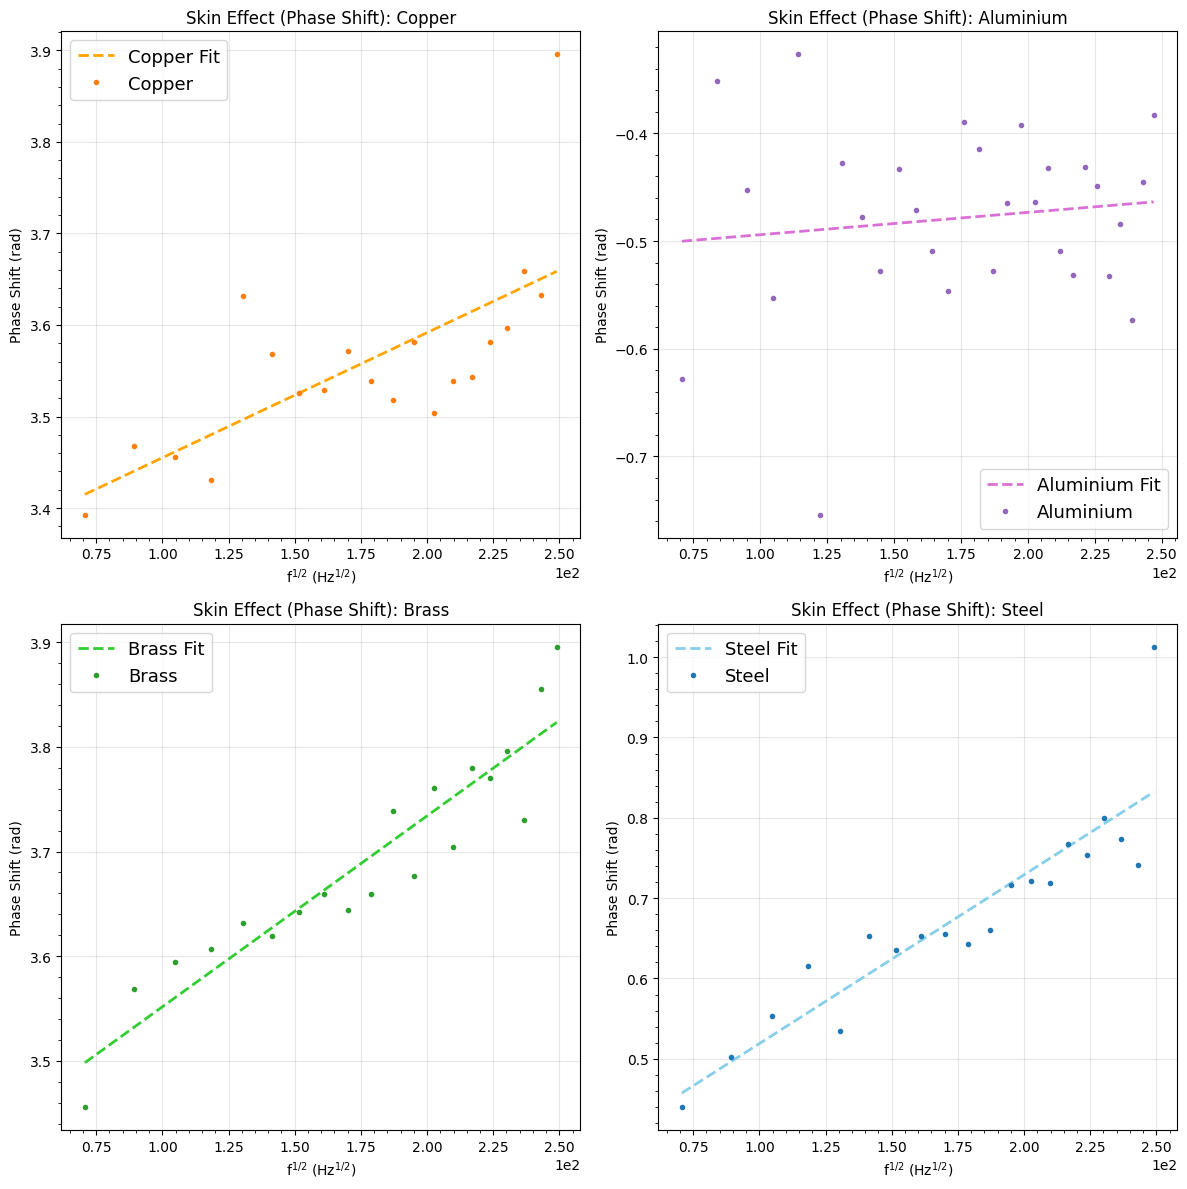

Copper Phase Slope = 0.0013659936317991146
Aluminium Phase Slope = 0.0002072241482215172
Brass Phase Slope = 0.0018243415055212355
Steel Phase Slope = 0.002101512670999721


In [215]:
xcopper = np.sqrt(copper_freq)
xalumin = np.sqrt(alumin_freq)
xbrass = np.sqrt(brass_freq)
xsteel = np.sqrt(steel_freq)

ycopper_phase = np.deg2rad(copper_phase)
acopperp, bcopperp = np.polyfit(xcopper, ycopper_phase, 1)
yalumin_phase = -1 * np.deg2rad(alumin_phase)
aaluminp, baluminp = np.polyfit(xalumin, yalumin_phase, 1)
ybrass_phase = np.deg2rad(brass_phase)
abrassp, bbrassp = np.polyfit(xbrass, ybrass_phase, 1)
ysteel_phase = np.deg2rad(steel_phase)
asteelp, bsteelp = np.polyfit(xsteel, ysteel_phase, 1)

fig, ax = plt.subplots(2,2, figsize=(12,12))

ax[0,0].errorbar(xcopper, ycopper_phase, fmt='.', color='tab:orange', label='Copper')
ax[0,0].plot(xcopper, acopperp*xcopper+bcopperp, color='orange', linestyle='--', linewidth=2, label='Copper Fit')
ax[0,0].set_title('Skin Effect (Phase Shift): Copper')
ax[0,0].set_xlabel(r'f$^{1/2}$ (Hz$^{1/2}$)')
ax[0,0].set_ylabel(r'Phase Shift (rad)')
ax[0,0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[0,0].minorticks_on()
ax[0,0].grid(which='major', alpha=0.3)
ax[0,0].legend(fontsize=13)

ax[0,1].errorbar(xalumin, yalumin_phase, fmt='.', color='tab:purple', label='Aluminium')
ax[0,1].plot(xalumin, aaluminp*xalumin+baluminp, color='orchid', linestyle='--', linewidth=2, label='Aluminium Fit')
ax[0,1].set_title('Skin Effect (Phase Shift): Aluminium')
ax[0,1].set_xlabel(r'f$^{1/2}$ (Hz$^{1/2}$)')
ax[0,1].set_ylabel(r'Phase Shift (rad)')
ax[0,1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[0,1].minorticks_on()
ax[0,1].grid(which='major', alpha=0.3)
ax[0,1].legend(fontsize=13, loc='lower right')

ax[1,0].errorbar(xbrass, ybrass_phase, fmt='.', color='tab:green', label='Brass')
ax[1,0].plot(xbrass, abrassp*xbrass+bbrassp, color='limegreen', linestyle='--', linewidth=2, label='Brass Fit')
ax[1,0].set_title('Skin Effect (Phase Shift): Brass')
ax[1,0].set_xlabel(r'f$^{1/2}$ (Hz$^{1/2}$)')
ax[1,0].set_ylabel(r'Phase Shift (rad)')
ax[1,0].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[1,0].minorticks_on()
ax[1,0].grid(which='major', alpha=0.3)
ax[1,0].legend(fontsize=13)

ax[1,1].errorbar(xsteel, ysteel_phase, fmt='.', color='tab:blue', label='Steel')
ax[1,1].plot(xsteel, asteelp*xsteel+bsteelp, color='skyblue', linestyle='--', linewidth=2, label='Steel Fit')
ax[1,1].set_title('Skin Effect (Phase Shift): Steel')
ax[1,1].set_xlabel(r'f$^{1/2}$ (Hz$^{1/2}$)')
ax[1,1].set_ylabel(r'Phase Shift (rad)')
ax[1,1].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[1,1].minorticks_on()
ax[1,1].grid(which='major', alpha=0.3) 
ax[1,1].legend(fontsize=13)

plt.tight_layout()
plt.show()

print(f'Copper Phase Slope = {acopperp}')
print(f'Aluminium Phase Slope = {aaluminp}')
print(f'Brass Phase Slope = {abrassp}')
print(f'Steel Phase Slope = {asteelp}')

In [212]:
G = acopperc * np.sqrt(cond_copper) # a = G * sqrt(mu_0 / sigma)
H = np.abs(acopperp) / np.sqrt(cond_copper)

cond_alumin_calc = (G / aaluminc)**2 # sigma = (G / a)^2
cond_brass_calc = (G / abrassc)**2 

#print(cond_alumin_calc, cond_brass_calc) # check to see if works

cond_steel = (np.abs(asteelp) / asteelc) * (G / H)
perm_steel = (asteelc * np.abs(asteelp)) / (G * H)

print(f"Calculated Steel Conductivity: {cond_steel:.2e} S/m")
print(f"Calculated Steel Relative Permeability: {perm_steel:.2f}") # likely a carbon steel (~100)

Calculated Steel Conductivity: 1.31e+06 S/m
Calculated Steel Relative Permeability: 95.90
